In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amineipad/titanic-dataset/train.csv
/kaggle/input/datasets/amineipad/titanic-dataset/test.csv


# Titanic Survival Analysis using Python

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Titanic dataset, identify missing values, visualize important patterns, and derive meaningful insights.

In [2]:
import pandas as pd

In [3]:
import os

os.listdir("/kaggle/input")

['datasets']

In [4]:
import os

os.listdir("/kaggle/input/datasets")

['amineipad']

In [5]:
import os

os.listdir("/kaggle/input/datasets/amineipad")

['titanic-dataset']

In [6]:
import os

os.listdir("/kaggle/input/datasets/amineipad/titanic-dataset")

['train.csv', 'test.csv']

In [7]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/amineipad/titanic-dataset/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.shape

(891, 12)

In [9]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Titanic Dataset Analysis

## Objective

The objective of this notebook is to explore the Titanic dataset, understand its structure, identify missing values, and perform basic exploratory data analysis.


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [14]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

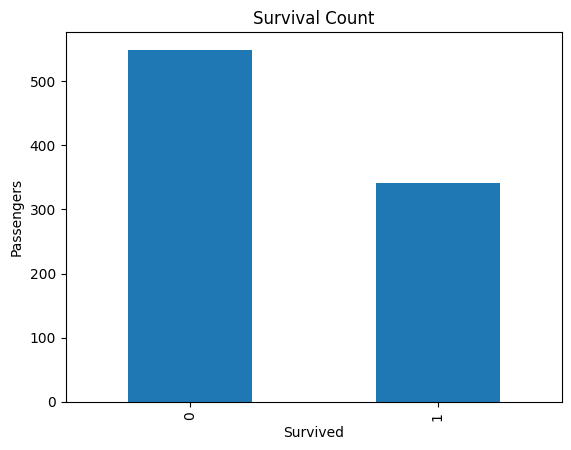

In [15]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")

plt.show()

The majority of passengers did not survive the Titanic disaster. The number of deaths was significantly higher than the number of survivors, indicating a relatively low overall survival rate.

In [16]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

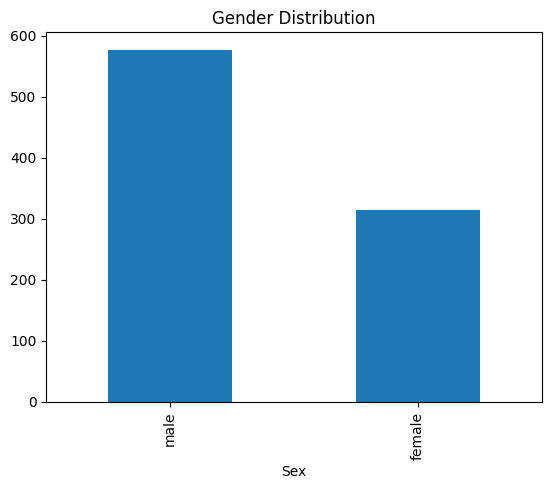

In [17]:
df["Sex"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")

plt.show()

Observation

Male passengers constituted a larger proportion of the dataset than female passengers. This indicates that more men were travelling on the Titanic.

In [18]:
df.groupby("Pclass")["Fare"].mean().round(2)

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

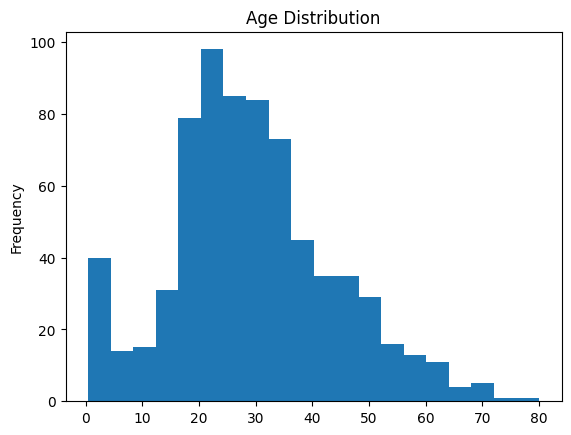

In [19]:
df["Age"].plot(kind="hist", bins=20)

plt.title("Age Distribution")

plt.show()

Most passengers were between 20 and 40 years of age. The dataset contains fewer elderly passengers and a small number of children.

In [20]:
df.groupby("Sex")["Age"].mean().round(2)

Sex
female    27.92
male      30.73
Name: Age, dtype: float64

In [21]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [22]:
df.nlargest(10,"Fare")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C


## Business Insights

- Most passengers belonged to 3rd class.
- Male passengers were more than female passengers.
- The Age column contains missing values.
- Cabin has a large number of missing values.
- Most passengers were between 20–40 years old.
- Survival rate was lower than the death rate.

## Conclusion

The Titanic dataset contains passenger demographic and travel information. Initial exploration shows missing values in Age and Cabin, a higher proportion of male passengers, and most travelers belonging to the third passenger class. Further analysis and predictive modeling can help identify the factors affecting passenger survival.

In [23]:
df.to_csv("cleaned_titanic.csv", index=False)

In [24]:
(df["Survived"].value_counts(normalize=True) * 100).round(2)

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

In [25]:
df["Age"].mean()

np.float64(29.69911764705882)

In [26]:
df["Fare"].mean()


np.float64(32.204207968574636)

In [27]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [28]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [29]:
(df["Age"].isnull().sum()/len(df))*100

np.float64(19.865319865319865)

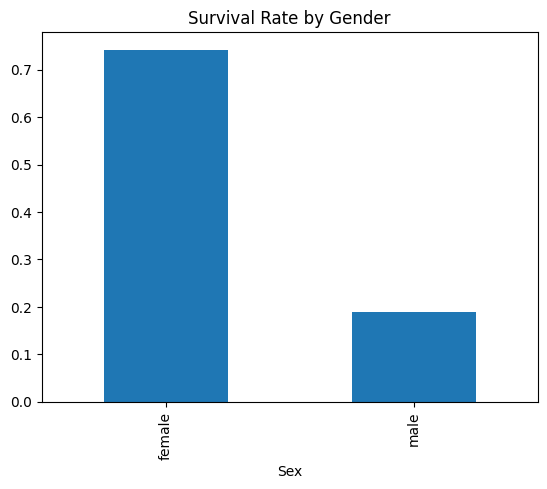

In [30]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.show()

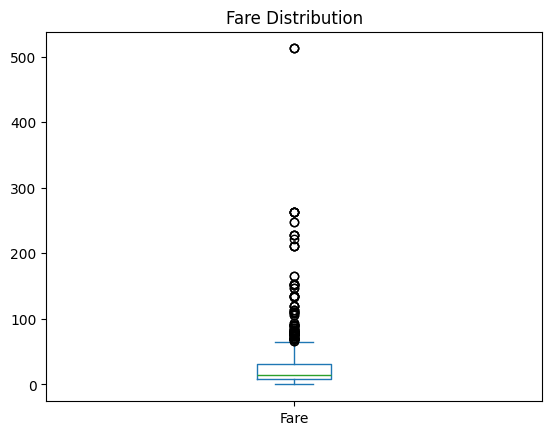

In [31]:
df["Fare"].plot(kind="box")

plt.title("Fare Distribution")
plt.show()

The fare distribution contains several high-value outliers, indicating that a small number of passengers paid significantly higher ticket prices than the majority.

In [32]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [33]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [34]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [35]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


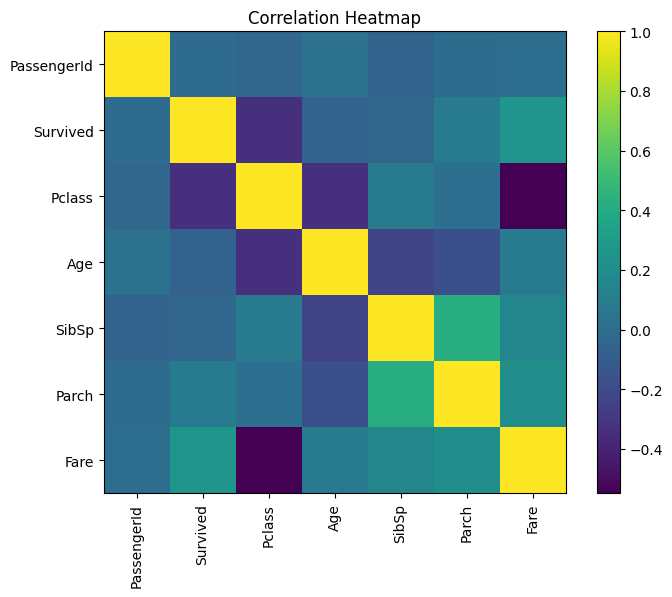

In [36]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

Most numerical features show weak correlations with each other. However, Passenger Class and Fare exhibit a noticeable relationship, while the Survival column shows meaningful associations with Passenger Class and Fare.

In [37]:
df.nlargest(10, "Fare")[["Name", "Fare", "Pclass"]]

,Name,Fare,Pclass
258,"Ward, Miss. Anna",512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1
737,"Lesurer, Mr. Gustave J",512.3292,1
27,"Fortune, Mr. Charles Alexander",263.0000,1
88,"Fortune, Miss. Mabel Helen",263.0000,1
341,"Fortune, Miss. Alice Elizabeth",263.0000,1
438,"Fortune, Mr. Mark",263.0000,1
311,"Ryerson, Miss. Emily Borie",262.3750,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",262.3750,1
118,"Baxter, Mr. Quigg Edmond",247.5208,1


In [38]:
df.groupby("Sex")["Survived"].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [39]:
df.groupby("Pclass")["Survived"].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [40]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [41]:
df.groupby("Sex")["Age"].mean()

Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64

# Key Findings

- The dataset contains 891 passenger records.
- Cabin had the highest number of missing values and was removed.
- Missing values in Age and Embarked were handled.
- Most passengers travelled in 3rd class.
- Female passengers had a much higher survival rate than male passengers.
- First-class passengers survived more often than third-class passengers.
- Most passengers were between 20 and 40 years old.

# Recommendations

- Handle missing values before performing any analysis or model building.
- Remove or appropriately treat columns with excessive missing values, such as Cabin.
- Passenger Class, Gender, and Fare should be considered as important features for predictive modeling.
- Investigate outliers in the Fare column before advanced analysis.
- Perform additional feature engineering, such as creating Family Size or Is Alone features, to improve future analysis.

# Conclusion

This exploratory data analysis provided valuable insights into the Titanic dataset. After cleaning the data and performing visual analysis, it was observed that passenger class, gender, and fare were strongly associated with survival. These findings provide a solid foundation for future predictive modeling and machine learning tasks.

# Limitations

- Missing values in the original dataset may influence the analysis.
- The analysis is exploratory and does not establish causal relationships.
- No predictive machine learning model has been developed in this notebook.

# Future Work

- Perform feature engineering to create new meaningful variables.
- Build machine learning models such as Logistic Regression and Decision Trees.
- Compare multiple classification algorithms to improve prediction accuracy.
- Evaluate model performance using accuracy, precision, recall, and F1-score.

# Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insight Generation

# Thank You

Thank you for exploring this notebook.

If you found this analysis useful, feel free to upvote the notebook and share your feedback.